In [1]:
# pip install kagglehub

In [2]:
# !pip install kagglehub
# !pip install datasets
# !pip install evaluate

In [3]:
# Import & download datset from kaggle
import kagglehub
mahmoudima_mma_facial_expression_path = kagglehub.dataset_download('mahmoudima/mma-facial-expression')
msambare_fer2013_path = kagglehub.dataset_download('msambare/fer2013')
noamsegal_affectnet_training_data_path = kagglehub.dataset_download('noamsegal/affectnet-training-data')
mohammedabdeldayem_testing_fer_path = kagglehub.dataset_download('mohammedabdeldayem/testing-fer')

print('Data source import complete.')

100%|██████████| 166M/166M [00:09<00:00, 18.4MB/s]

Extracting files...


100%|██████████| 60.3M/60.3M [00:03<00:00, 16.8MB/s]

Extracting files...


100%|██████████| 314M/314M [00:15<00:00, 21.1MB/s]

Extracting files...


100%|██████████| 94.2k/94.2k [00:00<00:00, 426kB/s]

Extracting files...
Data source import complete.


In [4]:
# notebook_login()

In [5]:
pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 16.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,roc_auc_score,confusion_matrix,classification_report,f1_score
import cv2
import os
import torch
import seaborn as sns
from sklearn.model_selection import train_test_split
from datasets import load_dataset,concatenate_datasets
from huggingface_hub import notebook_login
from transformers import AutoImageProcessor, AutoModelForImageClassification, TrainingArguments, Trainer, pipeline
from torchvision.transforms import (  # Import image transformation functions
    CenterCrop,  # Center crop an image
    Compose,  # Compose multiple image transformations
    Normalize,  # Normalize image pixel values
    RandomRotation,  # Apply random rotation to images
    RandomResizedCrop,  # Crop and resize images randomly
    RandomHorizontalFlip,  # Apply random horizontal flip
    RandomAdjustSharpness,  # Adjust sharpness randomly
    Resize,  # Resize images
    ToTensor  # Convert images to PyTorch tensors
)
import itertools  # Import 'itertools' for iterators and looping

In [7]:
model_checkpoint = "motheecreator/vit-Facial-Expression-Recognition" # pre-trained model from which to fine-tune

In [8]:
pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 5.8 MB/s eta 0:00:00


In [9]:
from evaluate import load

# Load the accuracy metric
metric = load("accuracy")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("noamsegal/affectnet-training-data")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/noamsegal/affectnet-training-data/versions/3


In [11]:
from datasets import load_dataset

af_dataset = load_dataset("imagefolder", data_dir=path)

Resolving data files:   0%|          | 0/29043 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [12]:
af_dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 29042
    })
})

In [13]:
from datasets import DatasetDict, ClassLabel

# Assuming `dataset` is already defined
# Get the label names
label_names = af_dataset['train'].features['label'].names

# Get the index of the 'contempt' label
contempt_index = label_names.index('contempt')

# Filter out the rows with 'contempt' label
filtered_dataset = af_dataset['train'].filter(lambda example: example['label'] != contempt_index)

# Remove 'contempt' from the label names
new_label_names = [name for name in label_names if name != 'contempt']

# Create a new ClassLabel feature without 'contempt'
new_label_feature = ClassLabel(names=new_label_names)

# Function to remap labels to the new indices
def remap_label(label):
    return new_label_feature.str2int(label_names[label])

# Update the dataset's label feature
filtered_dataset = filtered_dataset.map(lambda example: {'label': remap_label(example['label'])})

# Update the dataset features
filtered_dataset = filtered_dataset.cast_column('label', new_label_feature)

# Update the DatasetDict
af_dataset = DatasetDict({'train': filtered_dataset})

# Verify the change
print(af_dataset)

Filter:   0%|          | 0/29042 [00:00<?, ? examples/s]

Map:   0%|          | 0/26171 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/26171 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 26171
    })
})


In [14]:
from datasets import DatasetDict, ClassLabel

# Assuming `dataset` is already defined

# Get the label names
label_names = af_dataset['train'].features['label'].names

# Check if 'anger' exists in label_names before changing it
if 'anger' in label_names:
    # Change 'anger' to 'angry' in label names
    new_label_names = [name if name != 'anger' else 'angry' for name in label_names]

    # Update the label names in the dataset
    af_dataset['train'] = af_dataset['train'].rename_column('label', 'old_label')
    af_dataset['train'] = af_dataset['train'].rename_column('old_label', 'label')

    # Update the label 'anger' to 'angry' in the dataset
    af_dataset['train'] = af_dataset['train'].map(lambda example: {'label': 'angry' if example['label'] == 'anger' else example['label']})

    # Update the ClassLabel feature
    new_label_feature = ClassLabel(names=new_label_names)

    # Update the dataset's label feature
    af_dataset['train'] = af_dataset['train'].cast_column('label', new_label_feature)

# Verify the change
print(af_dataset)

Map:   0%|          | 0/26171 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/26171 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 26171
    })
})


In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/msambare/fer2013/versions/1


In [16]:
fer_dataset = load_dataset("imagefolder", data_dir=path)

Resolving data files:   0%|          | 0/28709 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/7178 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [17]:
fer_dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 28709
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 7178
    })
})

In [18]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mahmoudima/mma-facial-expression")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/mahmoudima/mma-facial-expression/versions/1


In [19]:
mmi_dataset = load_dataset("imagefolder", data_dir=path)

Resolving data files:   0%|          | 0/92968 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17356 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17356 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [20]:
mmi_dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 92968
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 17356
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 17356
    })
})

In [21]:
# # Get the label names from the mmi_dataset
# label_names_mmi = mmi_dataset['train'].features['label'].names

In [22]:
# mmi_label_mapping = {
#     i: label_names.index(label) if label in label_names and label != 'contempt' else -1  # -1 for unknown labels and 'contempt'
#     for i, label in enumerate(label_names_mmi)
# }

In [23]:
# # Map mmi_dataset labels to the first dataset's labels, excluding 'contempt'
# mmi_dataset['train'] = mmi_dataset['train'].map(
#     lambda example: {'label': mmi_label_mapping[example['label']]},
#     num_proc=4,  # Use multiple processes to speed up
# )
# mmi_dataset['train'] = mmi_dataset['train'].filter(lambda example: example['label'] != -1)  # Remove 'contempt' samples

# # Update the ClassLabel feature for mmi_dataset
# mmi_dataset['train'] = mmi_dataset['train'].cast_column('label', ClassLabel(names=label_names))


In [24]:
combined_dataset = concatenate_datasets([af_dataset['train'],fer_dataset['train'],mmi_dataset['train']])

In [25]:
dataset = DatasetDict()

In [26]:
dataset['train'] = combined_dataset

In [27]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 147848
    })
})

In [28]:
dataset['train'][0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=96x96>,
 'label': 0}

In [29]:
dataset['train'].features

{'image': Image(mode=None, decode=True, id=None),
 'label': ClassLabel(names=['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'], id=None)}

In [30]:
labels = dataset["train"].features["label"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label

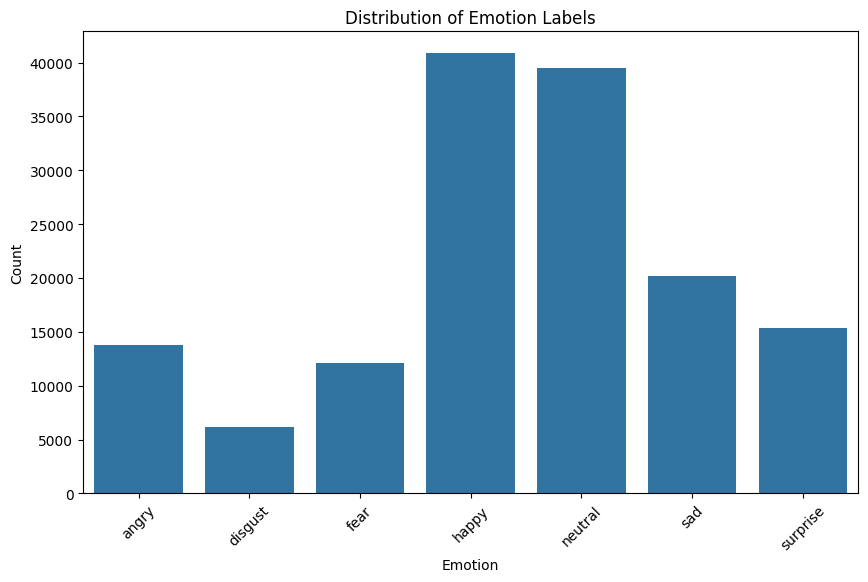

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter


# Visualize the distribution of labels in the dataset
label_counts = dataset['train'].features['label'].names
label_counts_dict = dict(Counter(dataset['train']['label']))  # Use Counter to count occurrences

# Map numerical labels to their names using id2label
label_counts_dict = {id2label[label]: count for label, count in label_counts_dict.items()}

plt.figure(figsize=(10, 6))
sns.barplot(x=list(label_counts_dict.keys()), y=list(label_counts_dict.values()))
plt.title('Distribution of Emotion Labels')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

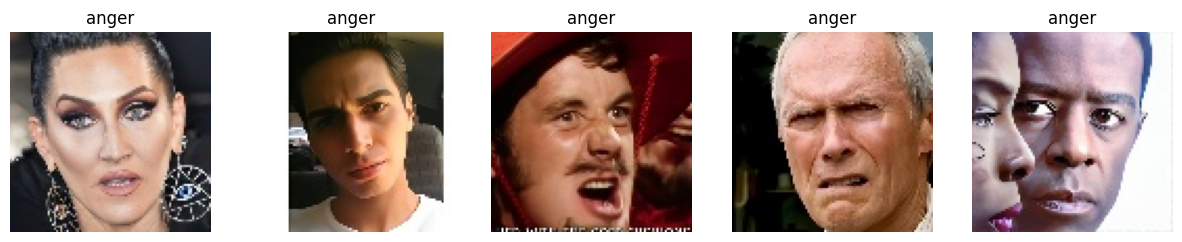

In [32]:
# Show some sample images from the dataset
def show_samples(dataset, n=5):
    plt.figure(figsize=(15, 10))
    for i in range(n):
        ax = plt.subplot(1, n, i + 1)
        image = dataset['train'][i]['image']
        label = dataset['train'][i]['label']
        plt.imshow(image)
        ax.set_title(label_names[label])
        plt.axis("off")
    plt.show()

show_samples(dataset)


In [33]:
label2id

{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'neutral': 4,
 'sad': 5,
 'surprise': 6}

In [34]:
image_processor  = AutoImageProcessor.from_pretrained(model_checkpoint)
image_processor

preprocessor_config.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

ViTImageProcessor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

In [35]:
# Retrieve the image mean and standard deviation used for normalization
image_mean, image_std = image_processor.image_mean, image_processor.image_std

# Get the size (height) of the ViT model's input images
size = image_processor.size["height"]
print("Size: ", size)

# Define a normalization transformation for the input images
normalize = Normalize(mean=image_mean, std=image_std)

# Define a set of transformations for training data
train_tf = Compose(
    [
        Resize((size, size)),             # Resize images to the ViT model's input size
        RandomRotation(90),               # Apply random rotation
        RandomAdjustSharpness(2),         # Adjust sharpness randomly
        RandomHorizontalFlip(0.5),        # Random horizontal flip
        ToTensor(),                       # Convert images to tensors
        normalize                          # Normalize images using mean and std
    ]
)
# Define a set of transformations for validation data
val_tf = Compose(
    [
        Resize((size, size)),             # Resize images to the ViT model's input size
        ToTensor(),                       # Convert images to tensors
        normalize                         # Normalize images using mean and std
    ]
)

Size:  224


In [36]:
# Define a function to apply training transformations to a batch of examples
def train_transforms(examples):
    examples['pixel_values'] = [train_tf(image.convert("RGB")) for image in examples['image']]
    return examples

# Define a function to apply validation transformations to a batch of examples
def val_transforms(examples):
    examples['pixel_values'] = [val_tf(image.convert("RGB")) for image in examples['image']]
    return examples

In [37]:
# split up training into training + validation
splits = dataset["train"].train_test_split(test_size=0.2)
train_data = splits['train']
val_data = splits['test']

In [38]:
train_data

Dataset({
    features: ['image', 'label'],
    num_rows: 118278
})

In [39]:
val_data

Dataset({
    features: ['image', 'label'],
    num_rows: 29570
})

In [40]:
train_data[0]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=96x96>,
 'label': 4}

In [41]:
val_data[0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=L size=48x48>,
 'label': 2}

In [42]:
model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes = True,
)

config.json:   0%|          | 0.00/915 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

In [43]:
notebook_login()

In [48]:
model_name = model_checkpoint.split("/")[-1]

args = TrainingArguments(
    f"{model_name}",
    remove_unused_columns=False,
    logging_dir='/content/logs',
    evaluation_strategy="steps",
    save_strategy="steps",  # Align with evaluation_strategy
    learning_rate=3e-5,
    lr_scheduler_type="cosine",
    auto_find_batch_size=True,
    per_device_train_batch_size=256,
    gradient_accumulation_steps=8,
    per_device_eval_batch_size=256,
    weight_decay=0.1,
    num_train_epochs=2.3,
    warmup_steps=1000,
    logging_steps=50,
    eval_steps=250,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=True,
    report_to="none"
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [49]:
# the compute_metrics function takes a Named Tuple as input:
# predictions, which are the logits of the model as Numpy arrays,
# and label_ids, which are the ground-truth labels as Numpy arrays.
def compute_metrics(eval_pred):
    """Computes accuracy on a batch of predictions"""
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)

In [50]:
from torchvision import transforms

def collate_fn(examples):
    # Define a common size for all images
    image_size = (224, 224)  # Adjust to your desired size

    # Apply transformations to each image: convert to tensor, resize, and ensure 3 channels
    pixel_values = torch.stack([
        transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize(image_size),
            # Ensure 3 channels using Lambda transform:
            transforms.Lambda(lambda image: image.repeat(3, 1, 1) if image.shape[0] == 1 else image)
        ])(example["image"]) for example in examples
    ])

    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [51]:
trainer = Trainer(
    model,
    args,
    train_dataset=train_data,
    eval_dataset=val_data,
    tokenizer=image_processor,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)

<ipython-input-51-a35d21ec3329>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [52]:
train_results = trainer.train()

Step,Training Loss,Validation Loss,Accuracy
250,0.391500,0.393000,0.866588
500,0.277700,0.341268,0.884680


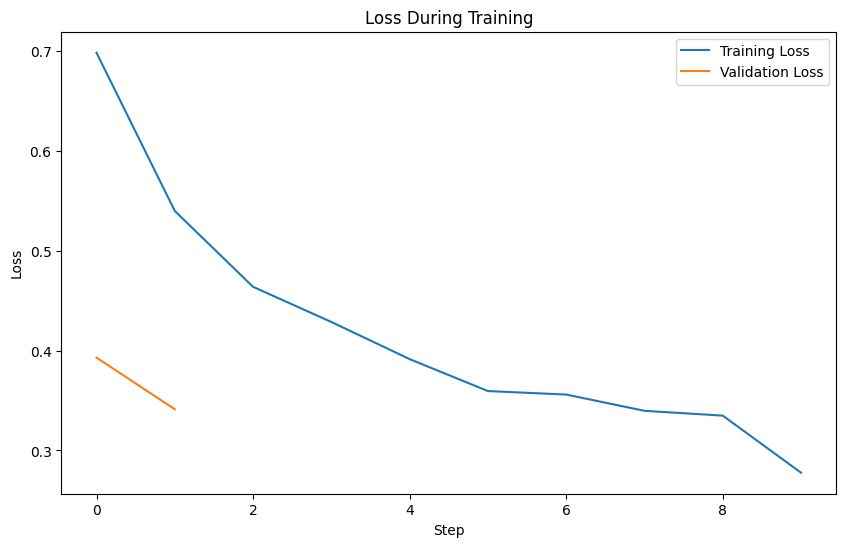

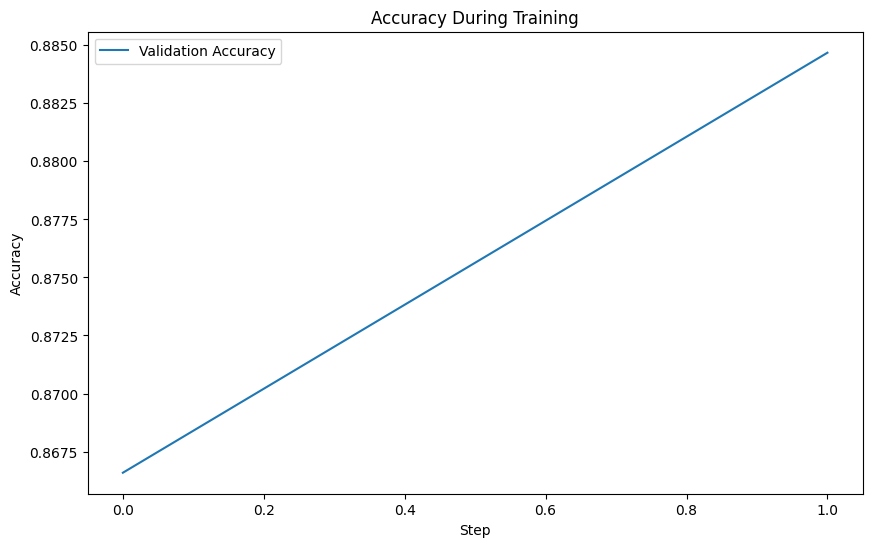

In [53]:
# Assuming trainer has already logged metrics
train_metrics = trainer.state.log_history

# Extract loss and accuracy
train_loss = [x['loss'] for x in train_metrics if 'loss' in x]
eval_loss = [x['eval_loss'] for x in train_metrics if 'eval_loss' in x]
train_accuracy = [x['eval_accuracy'] for x in train_metrics if 'eval_accuracy' in x]

# Plot Training Loss
plt.figure(figsize=(10, 6))
plt.plot(range(len(train_loss)), train_loss, label='Training Loss')
plt.plot(range(len(eval_loss)), eval_loss, label='Validation Loss')
plt.title('Loss During Training')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot Training Accuracy
plt.figure(figsize=(10, 6))
plt.plot(range(len(train_accuracy)), train_accuracy, label='Validation Accuracy')
plt.title('Accuracy During Training')
plt.xlabel('Step')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [54]:
# Save the model, processor, and tokenizer
model_checkpoint = "motheecreator/vit-Facial-Expression-Recognition"  # Change to your model checkpoint name

# Save the trained model
model.save_pretrained("saved_model/")

# Save the image processor (for future use to preprocess video frames)
image_processor.save_pretrained("saved_model/")


['saved_model/preprocessor_config.json']

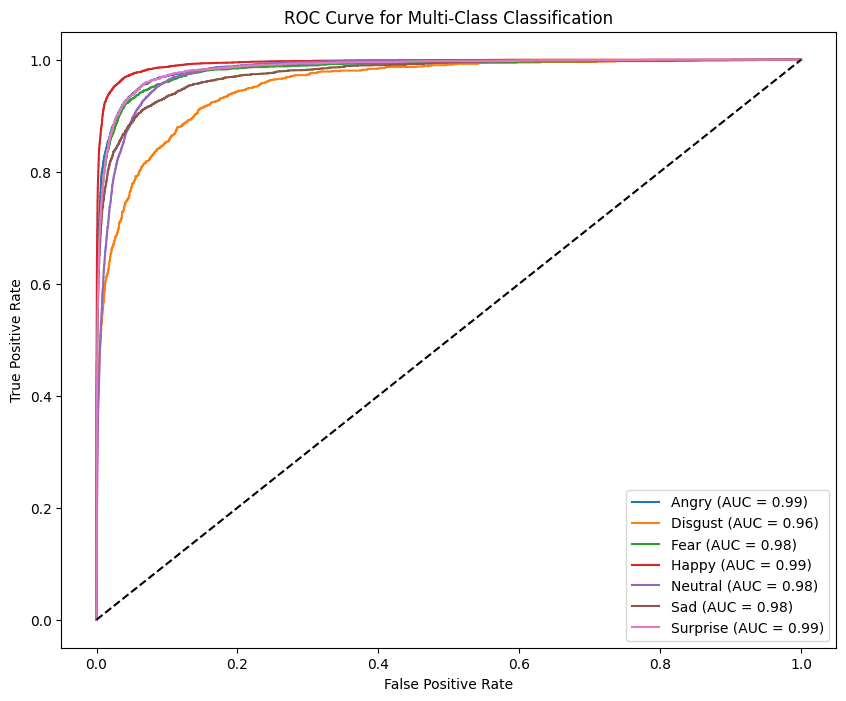

In [57]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# **Define labels_list**
labels_list = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise'] # Replace with your actual labels

# Calculate ROC curve for each class
n_classes = len(labels_list)
fpr = {}
tpr = {}
roc_auc = {}

# Assuming y_true and outputs.predictions are available
# y_true: True labels for the dataset
# outputs.predictions: Predicted probabilities for each class

# Check if y_true and outputs.predictions are defined
# If not, define them according to your data

# Get the trainer predictions
outputs = trainer.predict(val_data)  # Assuming 'trainer' and 'val_data' are defined

# Extract the true labels and predicted probabilities
y_true = outputs.label_ids
y_pred_probs = outputs.predictions  # Predicted probabilities

# Compute ROC curve and ROC area for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true == i, y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{labels_list[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve for Multi-Class Classification')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

In [56]:
metrics = trainer.evaluate()
# some nice to haves:
trainer.log_metrics("eval", metrics)
trainer.save_metrics("eval", metrics)

***** eval metrics *****
  epoch                   =     2.3018
  eval_accuracy           =     0.8847
  eval_loss               =     0.3413
  eval_runtime            = 0:06:42.20
  eval_samples_per_second =     73.519
  eval_steps_per_second   =      0.288


In [58]:
import shutil

# Zip the saved model folder
shutil.make_archive('saved_model', 'zip', 'saved_model')

'/content/saved_model.zip'

In [59]:
import shutil

# Zip the saved model folder
shutil.make_archive('vit-Facial-Expression-Recognition', 'zip', 'vit-Facial-Expression-Recognition')
shutil.make_archive('logs', 'zip', 'logs')


'/content/logs.zip'

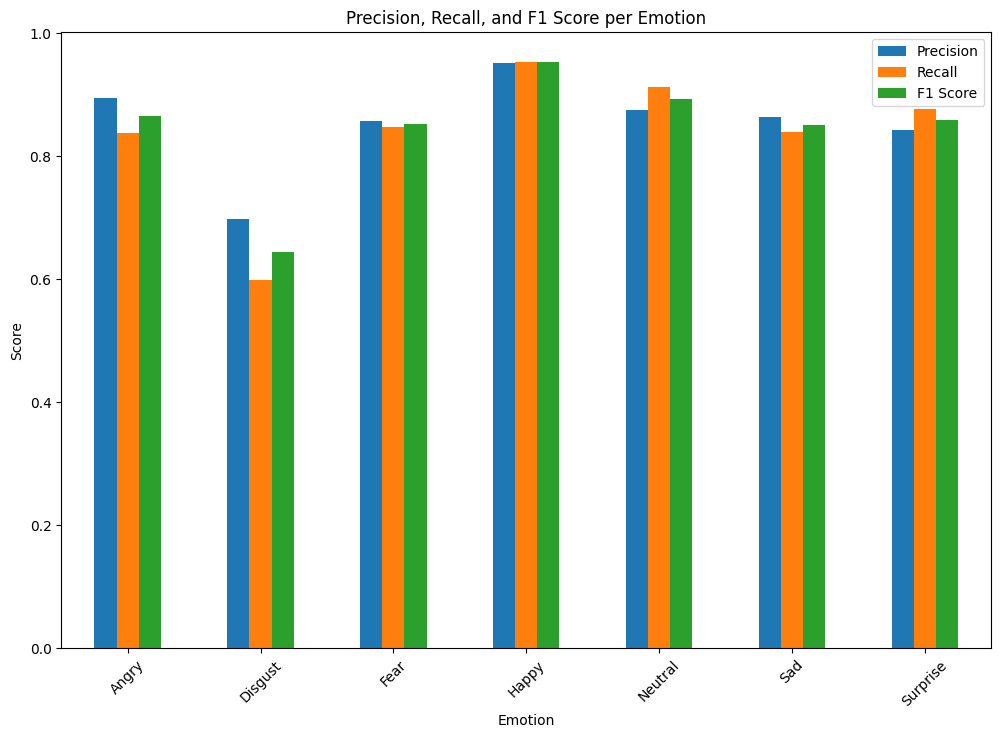

In [62]:
from sklearn.metrics import precision_recall_fscore_support

# Get the trainer predictions
# outputs = trainer.predict(val_data)  # Assuming 'trainer' and 'val_data' are defined

# Extract the true labels from the model outputs
y_true = outputs.label_ids

# Predict the labels by selecting the class with the highest probability
y_pred = outputs.predictions.argmax(1) #This line is added to calculate y_pred

# Calculate precision, recall, and F1 scores
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

# Plot Precision, Recall, and F1 Score
metrics_df = pd.DataFrame({
    'Emotion': labels_list,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
})

metrics_df.set_index('Emotion', inplace=True)

# Plot metrics
metrics_df.plot(kind='bar', figsize=(12, 8))
plt.title('Precision, Recall, and F1 Score per Emotion')
plt.ylabel('Score')
plt.xlabel('Emotion')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# trainer.push_to_hub()

In [64]:
# Use the trained 'trainer' to make predictions on the 'test_data'.
# outputs = trainer.predict(val_data)

# Print the metrics obtained from the prediction outputs.
print(outputs.metrics)

{'test_loss': 0.3412676751613617, 'test_accuracy': 0.8846804193439297, 'test_runtime': 401.128, 'test_samples_per_second': 73.717, 'test_steps_per_second': 0.289}


In [65]:
pipe=pipeline(model = 'motheecreator/vit-Facial-Expression-Recognition')

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


In [67]:
# import cv2  # for video handling
# # Initialize video capture
# video_path = '/content/5.mp4'  # Replace with the actual path to your video file
# cap = cv2.VideoCapture(video_path)
# if not cap.isOpened():
#     print("Error: Unable to open video.")
#     exit()

# # List to store emotions for each frame
# frame_emotions = []

# while cap.isOpened():
#     ret, frame = cap.read()  # Read the next frame
#     if not ret:
#         break  # Exit the loop if no frame is returned

#     # Convert the frame from BGR to RGB (OpenCV uses BGR by default)
#     image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

#     # Get emotion prediction for the current frame
#     emotion = pipe(image)  # Assuming 'pipe' outputs emotion as a dictionary with 'label'

#     # Extract predicted emotion (e.g., 'happy', 'sad', etc.)
#     predicted_emotion = emotion[0]['label']
#     frame_emotions.append(predicted_emotion)

#     # Optionally, display the emotion on the video frame
#     cv2.putText(frame, f'Emotion: {predicted_emotion}', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
#     cv2.imshow('Emotion Detection', frame)  # Display the frame with emotion label

#     # Optionally, press 'q' to quit the video early
#     if cv2.waitKey(1) & 0xFF == ord('q'):
#         break

# # Release the video capture and close OpenCV windows
# cap.release()
# cv2.destroyAllWindows()

# # After video processing, determine the most frequent emotion across all frames
# most_frequent_emotion = max(set(frame_emotions), key=frame_emotions.count)
# print(f"Most Frequent Emotion: {most_frequent_emotion}")

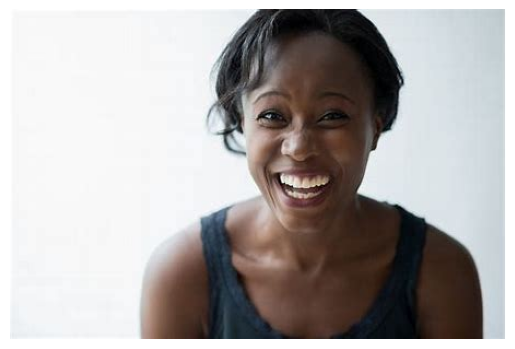

In [72]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load the image file
image_path = '/content/OIP.jpeg'  # Replace with the actual path to your image file
img = mpimg.imread(image_path)

# Display the image
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show()

In [73]:
pipe("/content/OIP.jpeg")

[{'label': 'happy', 'score': 0.937687337398529},
 {'label': 'surprise', 'score': 0.9000048637390137},
 {'label': 'disgust', 'score': 0.7926262021064758},
 {'label': 'anger', 'score': 0.631882905960083},
 {'label': 'fear', 'score': 0.3251822292804718}]

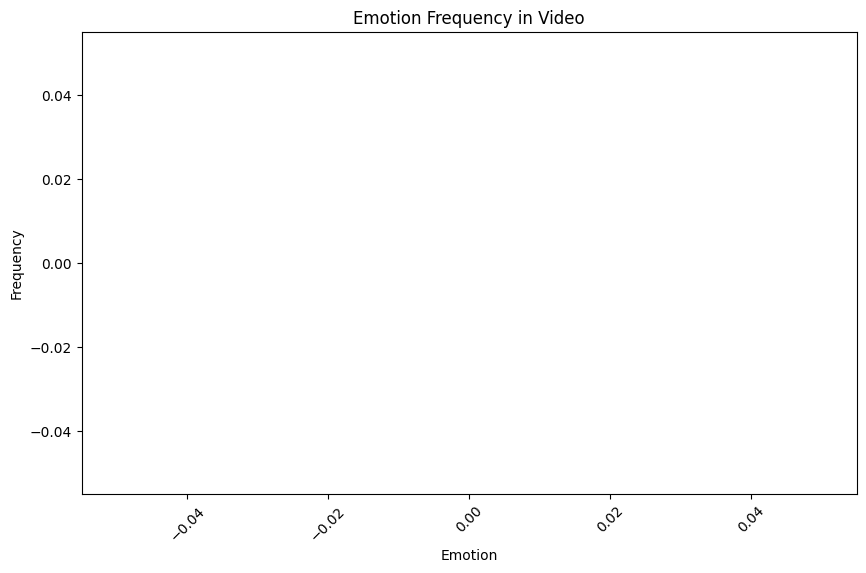

In [68]:
import matplotlib.pyplot as plt
from collections import Counter

# Count the frequency of each predicted emotion
emotion_counter = Counter(frame_emotions)

# Plot frequency of emotions
plt.figure(figsize=(10, 6))
plt.bar(emotion_counter.keys(), emotion_counter.values())
plt.title('Emotion Frequency in Video')
plt.xlabel('Emotion')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


In [69]:
# import matplotlib.pyplot as plt
# import matplotlib.image as mpimg

# # Load the image file
# image_path = '/kaggle/input/testing-fer/testing_FER/happy2.jpg'  # Replace with the actual path to your image file
# img = mpimg.imread(image_path)

# # Display the image
# plt.imshow(img)
# plt.axis('off')  # Turn off axis labels
# plt.show()

In [70]:
# pipe("/kaggle/input/testing-fer/testing_FER/happy2.jpg")

Accuracy: 0.8847
F1 Score: 0.8453


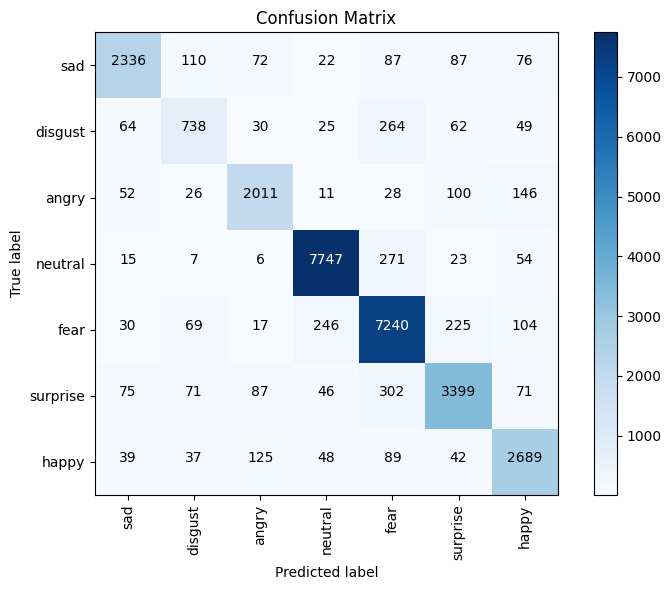


Classification report:

              precision    recall  f1-score   support

         sad     0.8947    0.8373    0.8650      2790
     disgust     0.6975    0.5990    0.6445      1232
       angry     0.8565    0.8471    0.8518      2374
     neutral     0.9511    0.9537    0.9524      8123
        fear     0.8743    0.9129    0.8932      7931
    surprise     0.8631    0.8391    0.8509      4051
       happy     0.8432    0.8762    0.8594      3069

    accuracy                         0.8847     29570
   macro avg     0.8544    0.8379    0.8453     29570
weighted avg     0.8838    0.8847    0.8838     29570



In [71]:
labels_list = ['sad', 'disgust', 'angry', 'neutral', 'fear', 'surprise', 'happy'] # list(set(labels))
# Extract the true labels from the model outputs
y_true = outputs.label_ids

# Predict the labels by selecting the class with the highest probability
y_pred = outputs.predictions.argmax(1)

# Define a function to plot a confusion matrix
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues, figsize=(10, 8)):
    """
    This function plots a confusion matrix.

    Parameters:
        cm (array-like): Confusion matrix as returned by sklearn.metrics.confusion_matrix.
        classes (list): List of class names, e.g., ['Class 0', 'Class 1'].
        title (str): Title for the plot.
        cmap (matplotlib colormap): Colormap for the plot.
    """
    # Create a figure with a specified size
    plt.figure(figsize=figsize)

    # Display the confusion matrix as an image with a colormap
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    # Define tick marks and labels for the classes on the axes
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    fmt = '.0f'
    # Add text annotations to the plot indicating the values in the cells
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    # Label the axes
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    # Ensure the plot layout is tight
    plt.tight_layout()
    # Display the plot
    plt.show()

# Calculate accuracy and F1 score
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro')

# Display accuracy and F1 score
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

# Get the confusion matrix if there are a small number of labels
if len(labels_list) <= 150:
    # Compute the confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot the confusion matrix using the defined function
    plot_confusion_matrix(cm, labels_list, figsize=(8, 6))

# Finally, display classification report
print()
print("Classification report:")
print()
print(classification_report(y_true, y_pred, target_names=labels_list, digits=4))